In [1]:
import pandas as pd
import numpy as np

columns = [
    "Sample ID",
    "Clump Thickness",
    "Uniformity Cell Size",
    "Uniformity Cell Shape",
    "Marginal Adhesion",
    "Single Epithelial Cell Size",
    "Bare Nuclei",
    "Bland Chromatin",
    "Normal Nucleoli",
    "Mitoses",
    "Class"
]

df = pd.read_csv("../data/breast-cancer-wisconsin.data", header=None, names=columns)

df.head()

,Sample ID,Clump Thickness,Uniformity Cell Size,Uniformity Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [2]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values represented by ?:")
print((df == "?").sum())

Shape: (699, 11)

Data types:
Sample ID                       int64
Clump Thickness                 int64
Uniformity Cell Size            int64
Uniformity Cell Shape           int64
Marginal Adhesion               int64
Single Epithelial Cell Size     int64
Bare Nuclei                    object
Bland Chromatin                 int64
Normal Nucleoli                 int64
Mitoses                         int64
Class                           int64
dtype: object

Missing values represented by ?:
Sample ID                       0
Clump Thickness                 0
Uniformity Cell Size            0
Uniformity Cell Shape           0
Marginal Adhesion               0
Single Epithelial Cell Size     0
Bare Nuclei                    16
Bland Chromatin                 0
Normal Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [3]:
df = df[df["Bare Nuclei"] != "?"].copy()
df["Bare Nuclei"] = df["Bare Nuclei"].astype(int)

features = columns[1:-1]

df[features].describe()

,Clump Thickness,Uniformity Cell Size,Uniformity Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [4]:
class_counts = df["Class"].value_counts()
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages.round(2))

Class counts:
Class
2    444
4    239
Name: count, dtype: int64

Class percentages:
Class
2    65.01
4    34.99
Name: proportion, dtype: float64


Matplotlib is building the font cache; this may take a moment.


array([[<Axes: title={'center': 'Clump Thickness'}>,
        <Axes: title={'center': 'Uniformity Cell Size'}>,
        <Axes: title={'center': 'Uniformity Cell Shape'}>],
       [<Axes: title={'center': 'Marginal Adhesion'}>,
        <Axes: title={'center': 'Single Epithelial Cell Size'}>,
        <Axes: title={'center': 'Bare Nuclei'}>],
       [<Axes: title={'center': 'Bland Chromatin'}>,
        <Axes: title={'center': 'Normal Nucleoli'}>,
        <Axes: title={'center': 'Mitoses'}>]], dtype=object)

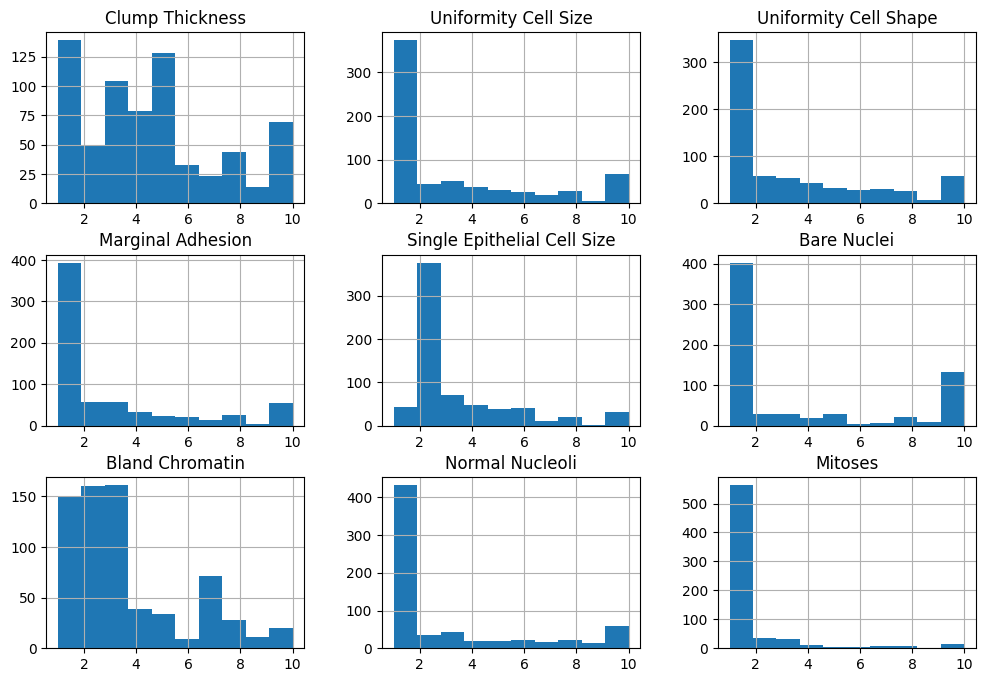

In [5]:
df[features].hist(figsize=(12, 8), bins=10)